In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
import pandas as pd

# URL del Google Sheet. Asegúrate de que la hoja esté compartida públicamente o con el email de tu cuenta Colab.
google_sheet_id = '1Mym1qj3qUCYrUznO9KVqiYW4lblNDUJQ'
google_sheet_url = f'https://docs.google.com/spreadsheets/d/{google_sheet_id}/export?format=xlsx'

# Carga el archivo Excel desde la URL en un DataFrame de pandas
df = pd.read_excel(google_sheet_url)

# Opcional: Muestra las primeras filas del DataFrame para verificar que se cargó correctamente.
print(df.head())

    N1  N2   N3  STE_mean   STE_std  CAA_mean   CAA_std  CAB_mean   CAB_std  \
0  750   0  750     13.88  2.027313  0.457580  0.003852  0.000000  0.000000   
1  750   0  750     13.60  3.055050  0.457724  0.005145  0.000000  0.000000   
2  749   2  749     13.36  2.970410  0.456295  0.005159  0.001177  0.000126   
3  749   2  749     14.36  3.120897  0.455526  0.004366  0.001219  0.000294   
4  748   4  748     12.92  1.891208  0.454844  0.003132  0.002282  0.000186   

   CAC_mean  ...  CBC_mean   CBC_std  CCC_mean   CCC_std  UnsatA_mean  \
0  0.084777  ...  0.000000  0.000000  0.457644  0.004136        67.40   
1  0.084188  ...  0.000000  0.000000  0.458088  0.005071        68.24   
2  0.085313  ...  0.001127  0.000134  0.456060  0.004856        70.00   
3  0.086588  ...  0.001098  0.000261  0.455512  0.003964        69.52   
4  0.085484  ...  0.002403  0.000248  0.454872  0.003582        67.20   

   UnsatA_std  UnsatB_mean  UnsatB_std  UnsatC_mean  UnsatC_std  
0   10.263203       

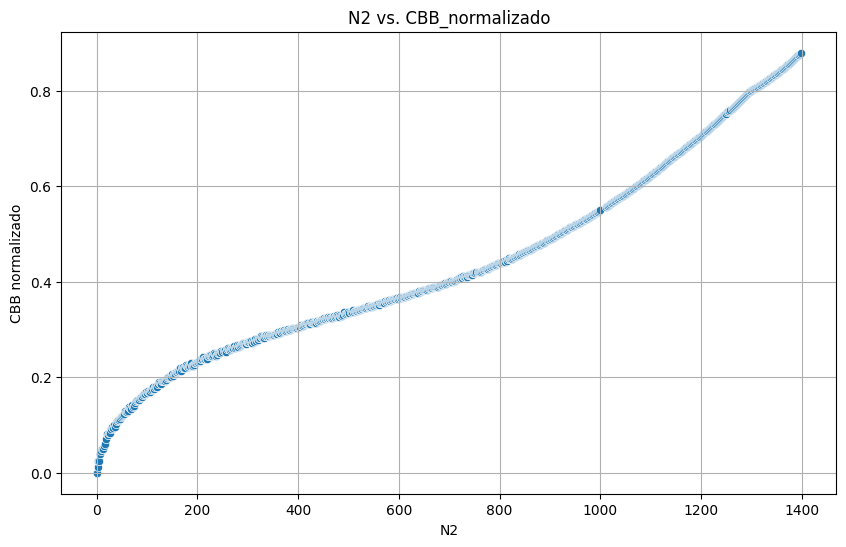

In [ ]:
df['CBB_ratio'] = df['CBB_mean'] / (df['CAB_mean'] + df['CBB_mean'] + df['CBC_mean'] + np.finfo(float).eps)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='N2', y='CBB_ratio', data=df)
plt.title('N2 vs. CBB_normalizado')
plt.xlabel('N2')
plt.ylabel('CBB normalizado')
plt.grid(True)
plt.show()


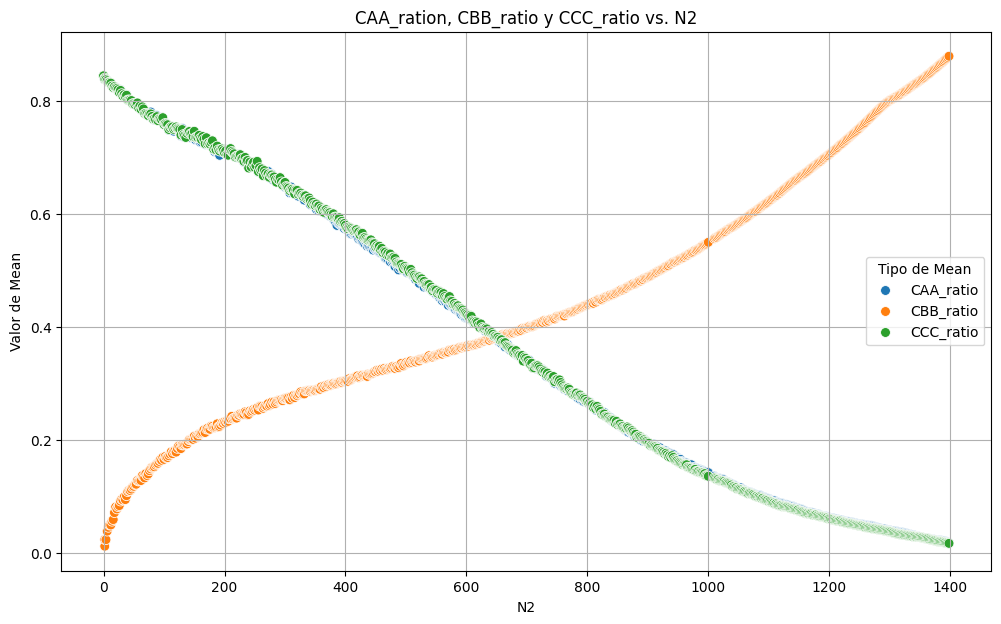

In [ ]:
df['CBB_ratio'] = df['CBB_mean'] / (df['CAB_mean'] + df['CBB_mean'] + df['CBC_mean'])
df['CAA_ratio'] = df['CAA_mean'] / (df['CAA_mean'] + df['CAB_mean'] + df['CAC_mean'])
df['CCC_ratio'] = df['CCC_mean'] / (df['CBC_mean'] + df['CCC_mean'] + df['CAC_mean'])

plot_columns = ['CAA_ratio', 'CBB_ratio', 'CCC_ratio']
required_columns = ['N2'] + plot_columns

# Melt el DataFrame para preparar los datos para graficar múltiples series
df_melted = df.melt(id_vars=['N2'], value_vars=plot_columns, var_name='Tipo_Mean', value_name='Valor_Mean')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='N2', y='Valor_Mean', hue='Tipo_Mean', data=df_melted, s=50)
plt.title('CAA_ration, CBB_ratio y CCC_ratio vs. N2')
plt.xlabel('N2')
plt.ylabel('Valor de Mean')
plt.grid(True)
plt.legend(title='Tipo de Mean')
plt.show()

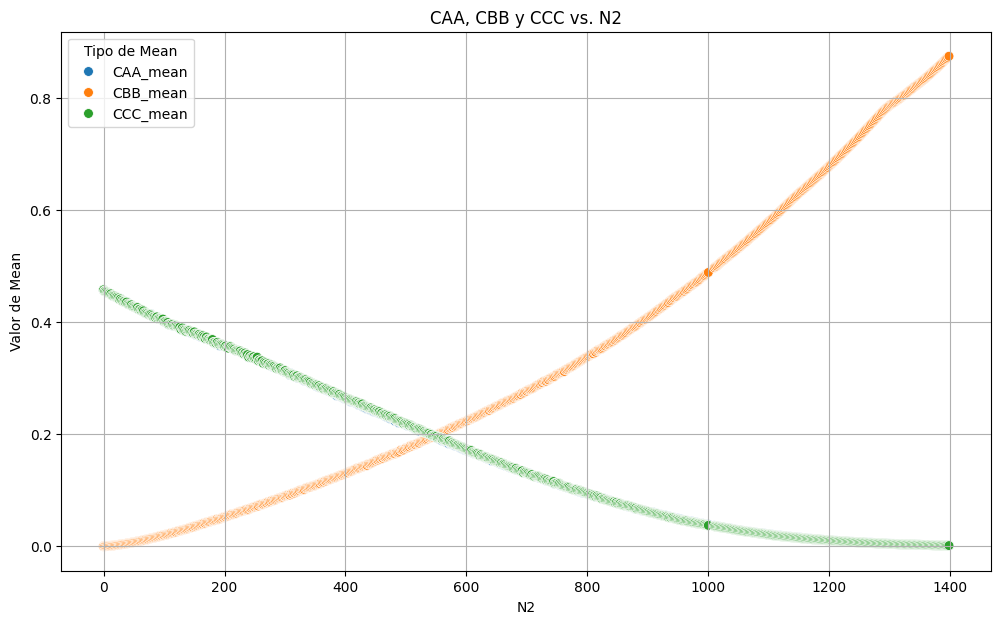

In [ ]:
plot_columns = ['CAA_mean', 'CBB_mean', 'CCC_mean']
required_columns = ['N2'] + plot_columns

# Melt el DataFrame para preparar los datos para graficar múltiples series
df_melted = df.melt(id_vars=['N2'], value_vars=plot_columns, var_name='Tipo_Mean', value_name='Valor_Mean')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='N2', y='Valor_Mean', hue='Tipo_Mean', data=df_melted, s=50)
plt.title('CAA, CBB y CCC vs. N2')
plt.xlabel('N2')
plt.ylabel('Valor de Mean')
plt.grid(True)
plt.legend(title='Tipo de Mean')
plt.show()

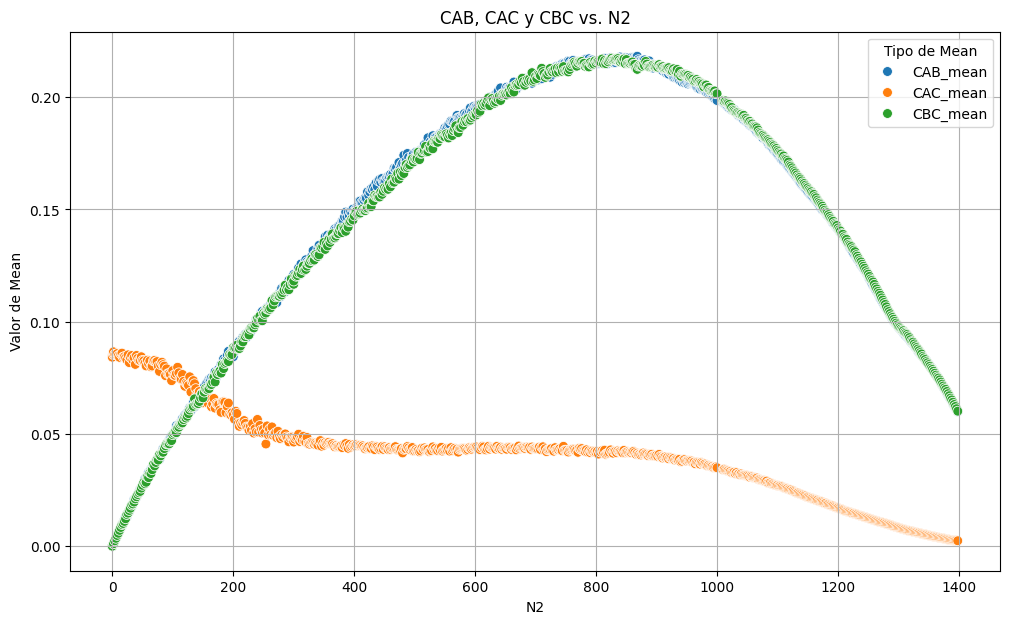

In [ ]:
plot_columns = ['CAB_mean', 'CAC_mean', 'CBC_mean']
required_columns = ['N2'] + plot_columns

# Melt el DataFrame para preparar los datos para graficar múltiples series
df_melted = df.melt(id_vars=['N2'], value_vars=plot_columns, var_name='Tipo_Mean', value_name='Valor_Mean')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='N2', y='Valor_Mean', hue='Tipo_Mean', data=df_melted, s=50)
plt.title('CAB, CAC y CBC vs. N2')
plt.xlabel('N2')
plt.ylabel('Valor de Mean')
plt.grid(True)
plt.legend(title='Tipo de Mean')
plt.show()

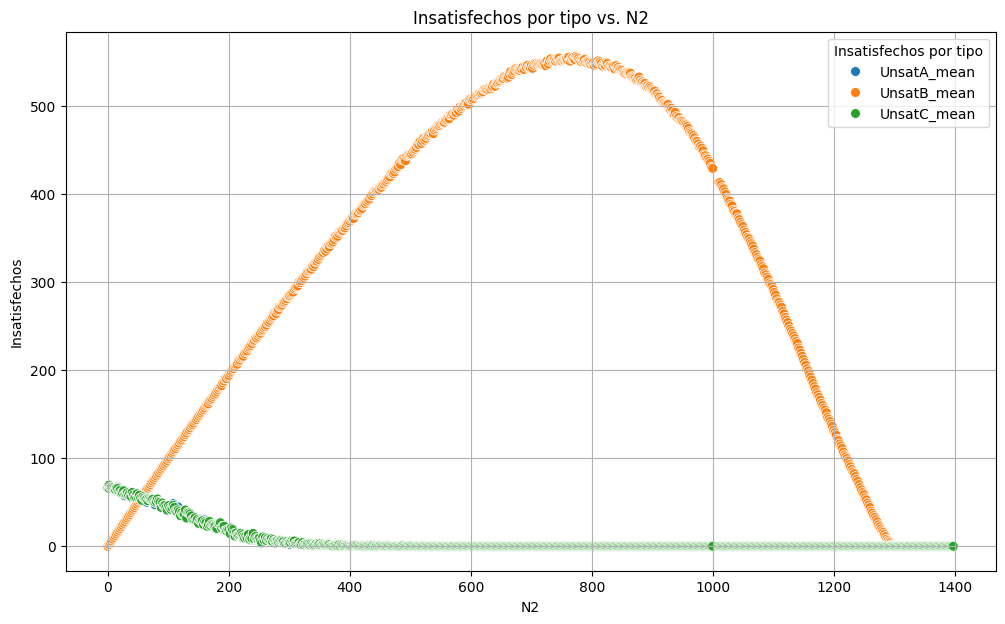

In [ ]:
plot_columns = ['UnsatA_mean', 'UnsatB_mean', 'UnsatC_mean']
required_columns = ['N2'] + plot_columns

# Melt el DataFrame para preparar los datos para graficar múltiples series
df_melted = df.melt(id_vars=['N2'], value_vars=plot_columns, var_name='Tipo', value_name='Valor')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='N2', y='Valor', hue='Tipo', data=df_melted, s=50)
plt.title('Insatisfechos por tipo vs. N2')
plt.xlabel('N2')
plt.ylabel('Insatisfechos')
plt.grid(True)
plt.legend(title='Insatisfechos por tipo')
plt.show()

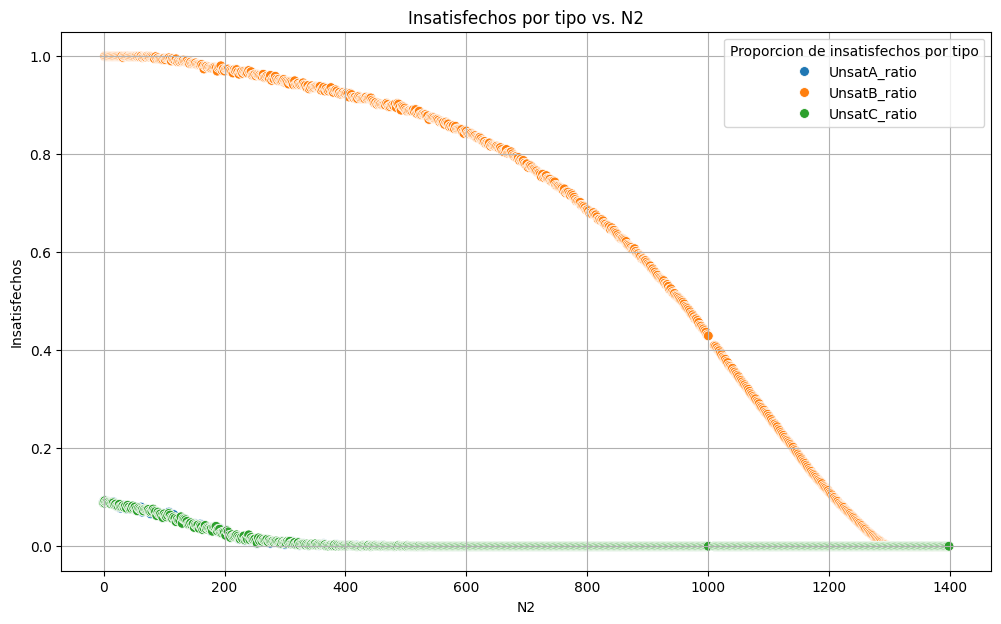

In [ ]:
df['UnsatA_ratio'] = df['UnsatA_mean'] / df['N1']
df['UnsatB_ratio'] = df['UnsatB_mean'] / df['N2']
df['UnsatC_ratio'] = df['UnsatC_mean'] / df['N3']
plot_columns = ['CAA_ratio', 'CBB_ratio', 'CCC_ratio']
required_columns = ['N2'] + plot_columns

plot_columns = ['UnsatA_ratio', 'UnsatB_ratio', 'UnsatC_ratio']
required_columns = ['N2'] + plot_columns

# Melt el DataFrame para preparar los datos para graficar múltiples series
df_melted = df.melt(id_vars=['N2'], value_vars=plot_columns, var_name='Tipo', value_name='Valor')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='N2', y='Valor', hue='Tipo', data=df_melted, s=50)
plt.title('Insatisfechos por tipo vs. N2')
plt.xlabel('N2')
plt.ylabel('Insatisfechos')
plt.grid(True)
plt.legend(title='Proporcion de insatisfechos por tipo')
plt.show()

In [1]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.scatterplot(x='N2', y='STE_mean', data=df)
plt.title('N2 vs. Promedio numero de pasos')
plt.xlabel('N2')
plt.ylabel('Numero de pasos promedio')
plt.grid(True)
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x600 with 0 Axes>